In [1]:
import pandas as pd
from pathlib import Path

# Set your Parquet file path here
path = "..\\raw_data\\ohlcv.parquet"
parquet_path = Path(path)

main_df = pd.read_parquet(parquet_path)
main_df

,symbol,date,open,high,low,close,volume
0,BRK-B,2011-01-27,82.739998,83.239998,82.650002,83.029999,2817800
1,BRK-B,2013-02-28,101.440002,102.330002,101.309998,102.160004,8875500
2,BRK-B,2013-03-01,101.449997,102.250000,100.440002,102.050003,4812800
3,BRK-B,2013-03-06,103.290001,103.559998,102.760002,103.239998,3316300
4,BRK-B,2013-03-15,103.669998,103.790001,102.790001,102.790001,7253800
...,...,...,...,...,...,...,...
4385661,HAS,2026-05-22,90.080002,90.360001,87.849998,88.099998,2234900
4385662,HAS,2026-05-26,88.519997,89.970001,87.500000,87.989998,2027500
4385663,HAS,2026-05-27,88.860001,89.790001,87.809998,87.989998,2424800
4385664,HAS,2026-05-28,88.040001,88.050003,85.910004,86.379997,2515500


In [2]:
# Filter the data from January 1, 2016 to December 31, 2025
main_df['date'] = pd.to_datetime(main_df['date'], errors='coerce')
main_df = main_df[(main_df['date'] >= '2016-01-01') & (main_df['date'] <= '2025-12-31')].copy()

# Filter to the first 500 unique stocks in the existing file order
first_500_symbols = main_df['symbol'].dropna().astype(str).drop_duplicates().head(500)
main_df = main_df[main_df['symbol'].astype(str).isin(first_500_symbols)].copy()

In [3]:
output_path = Path("..\\raw_data\\filter_OHLCV.parquet")
main_df.to_parquet(output_path, index=False)
print(f"Saved {len(main_df)} rows to {output_path}")

Saved 1220278 rows to ..\raw_data\filter_OHLCV.parquet


## Step:1 Load and datset overview

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Resetting the dataframe path to the original file for future use
new_path = "..\\data\\filter_OHLCV.parquet"
new_parquet_path = Path(new_path)

df = pd.read_parquet(new_parquet_path)
df

,symbol,date,open,high,low,close,volume
0,BRK-B,2016-01-08,130.110001,130.399994,128.210007,128.330002,6101600
1,BRK-B,2016-01-13,128.970001,129.380005,125.709999,126.250000,6042400
2,BRK-B,2016-01-15,125.339996,126.809998,124.510002,126.139999,8145100
3,BRK-B,2016-01-29,126.660004,129.770004,126.110001,129.770004,6523800
4,BRK-B,2016-02-03,126.339996,126.629997,123.550003,126.239998,6607500
...,...,...,...,...,...,...,...
1220273,VICI,2020-07-02,15.681162,15.740225,15.260340,15.400615,4136400
1220274,VICI,2020-07-06,15.799288,15.865734,14.902272,14.928112,4423500
1220275,VICI,2020-07-07,14.691864,15.105303,14.573738,14.758309,2779800
1220276,VICI,2020-07-08,14.809990,14.950265,14.621728,14.913351,2158800


In [5]:
# Set plotting style and figure size
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# Basic info about the dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nDate range:", df['date'].min(), "→", df['date'].max())
print("Unique stocks:", df['symbol'].nunique())
print("Total trading days per stock (avg):", round(df.groupby('symbol').size().mean(), 1))

Shape: (1220278, 7)

Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

Dtypes:
 symbol               str
date      datetime64[ms]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Date range: 2016-01-04 00:00:00 → 2025-12-31 00:00:00
Unique stocks: 500
Total trading days per stock (avg): 2440.6


## Step:2 Descriptive Statistics

In [6]:
# Overall descriptive statistics for numeric columns
desc = df[['open', 'high', 'low', 'close', 'volume']].describe().T
desc['median'] = df[['open', 'high', 'low', 'close', 'volume']].median()
desc['skewness'] = df[['open', 'high', 'low', 'close', 'volume']].skew()
desc['kurtosis'] = df[['open', 'high', 'low', 'close', 'volume']].kurtosis()
print(desc.round(4))

            count          mean           std     min           25%  \
open    1220278.0  1.291075e+02  2.701225e+02  0.6044  4.132850e+01   
high    1220278.0  1.305998e+02  2.733323e+02  0.6234  4.180040e+01   
low     1220278.0  1.275897e+02  2.670019e+02  0.6037  4.084200e+01   
close   1220278.0  1.291225e+02  2.701622e+02  0.6151  4.133420e+01   
volume  1220278.0  6.553134e+06  2.734128e+07  0.0000  1.022400e+06   

                 50%           75%           max        median  skewness  \
open    7.692130e+01  1.445747e+02  9.914170e+03  7.692130e+01   16.8218   
high    7.780520e+01  1.462170e+02  9.964770e+03  7.780520e+01   16.8095   
low     7.602860e+01  1.429289e+02  9.794000e+03  7.602860e+01   16.8411   
close   7.692330e+01  1.445894e+02  9.924400e+03  7.692330e+01   16.8152   
volume  2.191900e+06  5.073200e+06  3.692928e+09  2.191900e+06   24.5832   

         kurtosis  
open     402.6240  
high     401.7632  
low      403.5868  
close    402.1954  
volume  1121.516

In [7]:
# Per symbol Stats: avg closing price and volume, volatility (std of close), and trading frequency
symbol_stats = df.groupby('symbol').agg(
    avg_close=('close', 'mean'),
    std_close=('close', 'std'),
    avg_volume=('volume', 'mean'),
    trading_days=('date', 'count')
).sort_values('avg_close', ascending=False)

print("Top 10 highest avg price stocks:\n", symbol_stats.head(10))
print("\nTop 10 most traded stocks:\n", symbol_stats.sort_values('avg_volume', ascending=False).head(10))

Top 10 highest avg price stocks:
           avg_close    std_close    avg_volume  trading_days
symbol                                                      
NVR     4500.626078  2110.743117  2.487164e+04          2514
AZO     1724.514482  1034.008336  2.431223e+05          2514
MTD      970.290890   384.229421  1.517589e+05          2514
FICO     622.465237   577.286522  2.181589e+05          2514
BLK      576.834122   237.381403  6.688143e+05          2514
EQIX     567.331233   190.378787  5.246917e+05          2514
REGN     559.376094   201.568270  8.258362e+05          2514
TDG      552.810008   375.574751  4.054009e+05          2514
GWW      479.170514   297.123284  4.506095e+05          2514
COST     417.016592   270.743601  2.343027e+06          2514

Top 10 most traded stocks:
          avg_close   std_close    avg_volume  trading_days
symbol                                                    
NVDA     36.044211   51.193296  4.588549e+08          2514
TSLA    149.732458  131.0163

## Step:3 Missing Values Analysis


        Missing Count  Missing %
symbol              0        0.0
date                0        0.0
open                0        0.0
high                0        0.0
low                 0        0.0
close               0        0.0
volume              0        0.0
No missing values found.

Stocks with <90% date coverage: 30
symbol
Q         46
SNDK     222
GEV      443
SOLV     444
VLTO     563
KVUE     668
GEHC     763
CEG      992
HOOD    1112
APP     1185
Name: date, dtype: int64


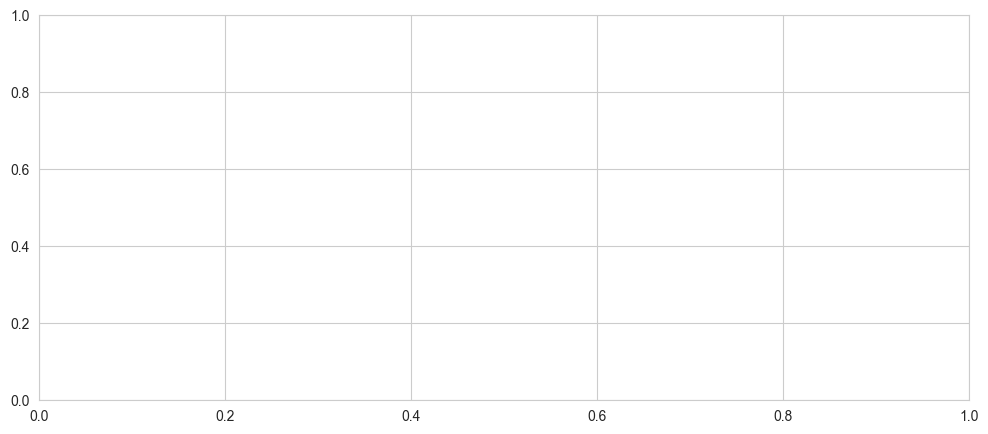

In [8]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(4)
})
print(missing_df)

# Plot only columns that actually have missing values
fig, ax = plt.subplots()
missing_to_plot = missing_pct[missing_pct > 0]

if len(missing_to_plot) > 0:
    missing_to_plot.plot(kind='bar', ax=ax, color='salmon')
    ax.set_title('Missing Value Percentage by Column')
    ax.set_ylabel('% Missing')
    ax.set_xlabel('Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

# Checking for stocks with incomplete date coverage
expected_days = df['date'].nunique()
stock_coverage = df.groupby('symbol')['date'].count()
incomplete_stocks = stock_coverage[stock_coverage < expected_days * 0.9]

print(f"\nStocks with <90% date coverage: {len(incomplete_stocks)}")
print(incomplete_stocks.sort_values().head(10))

## Step:4 Outlier Detection

In [9]:
# IQR method to count outliers in each numeric column
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

for col in ['open', 'high', 'low', 'close', 'volume']:
    n = count_outliers_iqr(df[col])
    print(f"{col}: {n} outliers ({n/len(df)*100:.2f}%)")

open: 90989 outliers (7.46%)
high: 91150 outliers (7.47%)
low: 90740 outliers (7.44%)
close: 90988 outliers (7.46%)
volume: 127161 outliers (10.42%)


In [10]:
from scipy.stats.mstats import winsorize
import numpy as np

# ── Winsorize at 1st and 99th percentile ─────────────────────────────
# This keeps all rows but caps the most extreme 1% on each tail

cols_to_winsorize = ['open', 'high', 'low', 'close', 'volume']

df_clean = df.copy()

for col in cols_to_winsorize:
    df_clean[col] = winsorize(df[col].fillna(df[col].median()), 
                               limits=[0.01, 0.01])

print("Winsorization complete.")
print(df_clean[cols_to_winsorize].describe().round(2))

Winsorization complete.


e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


             open        high         low       close       volume
count  1220278.00  1220278.00  1220278.00  1220278.00   1220278.00
mean       117.49      118.84      116.11      117.50   5382147.75
std        122.98      124.42      121.53      123.00  10153761.69
min          8.69        8.85        8.53        8.69    119400.00
25%         41.33       41.80       40.84       41.33   1022400.00
50%         76.92       77.81       76.03       76.92   2191900.00
75%        144.57      146.22      142.93      144.59   5073200.00
max        725.94      734.71      717.71      726.42  71165700.00


e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [11]:
# ── Log-transform volume instead of winsorizing ───────────────────────
# Volume outliers are often real (news events = high volume = signal!)
# Log compression reduces scale distortion while preserving the signal

df_clean['volume_log'] = np.log1p(df_clean['volume'])

# Verify
print("Original volume range:", df_clean['volume'].min(), "→", df_clean['volume'].max())
print("Log volume range:", df_clean['volume_log'].min().round(2), 
      "→", df_clean['volume_log'].max().round(2))

Original volume range: 119400 → 71165700
Log volume range: 11.69 → 18.08


In [12]:
# ── Confirm outlier reduction ─────────────────────────────────────────
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

print("Outliers AFTER winsorization:")
for col in ['open', 'high', 'low', 'close']:
    n = count_outliers_iqr(df_clean[col])
    print(f"  {col}: {n} ({n/len(df_clean)*100:.2f}%)")

Outliers AFTER winsorization:
  open: 90989 (7.46%)
  high: 91150 (7.47%)
  low: 90740 (7.44%)
  close: 90988 (7.46%)


e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
e:\Stock-Price-Prediction-using-Advanced-modelling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mas

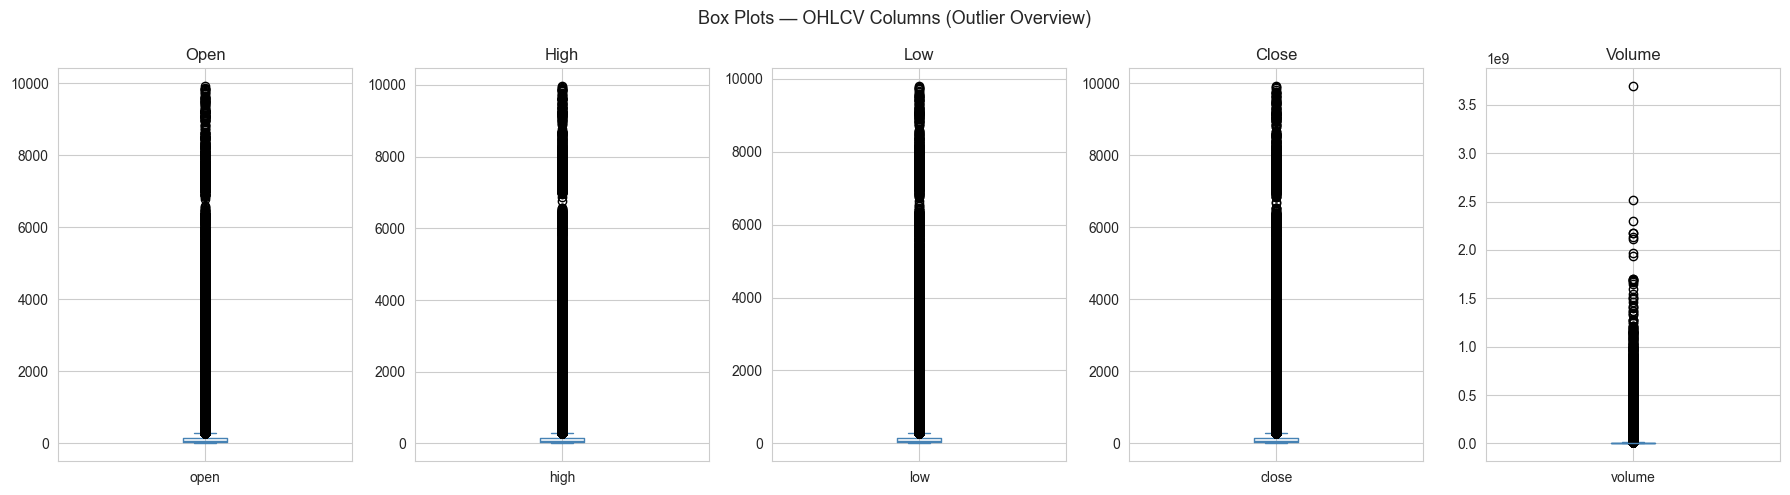

In [13]:
# Box plots for OHLCV columns to visualize outliers
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, ['open', 'high', 'low', 'close', 'volume']):
    df[col].plot(kind='box', ax=ax, color='steelblue')
    ax.set_title(col.capitalize())
    ax.set_xlabel('')
plt.suptitle('Box Plots — OHLCV Columns (Outlier Overview)', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# Data integrity check: high >= low, high >= close, etc.
invalid_hl = (df['high'] < df['low']).sum()
invalid_hc = (df['high'] < df['close']).sum()
invalid_lo = (df['low'] > df['open']).sum()
print(f"Rows where high < low: {invalid_hl}")
print(f"Rows where high < close: {invalid_hc}")
print(f"Rows where low > open: {invalid_lo}")

Rows where high < low: 0
Rows where high < close: 109
Rows where low > open: 1


## Step:5 Distribution Analysis

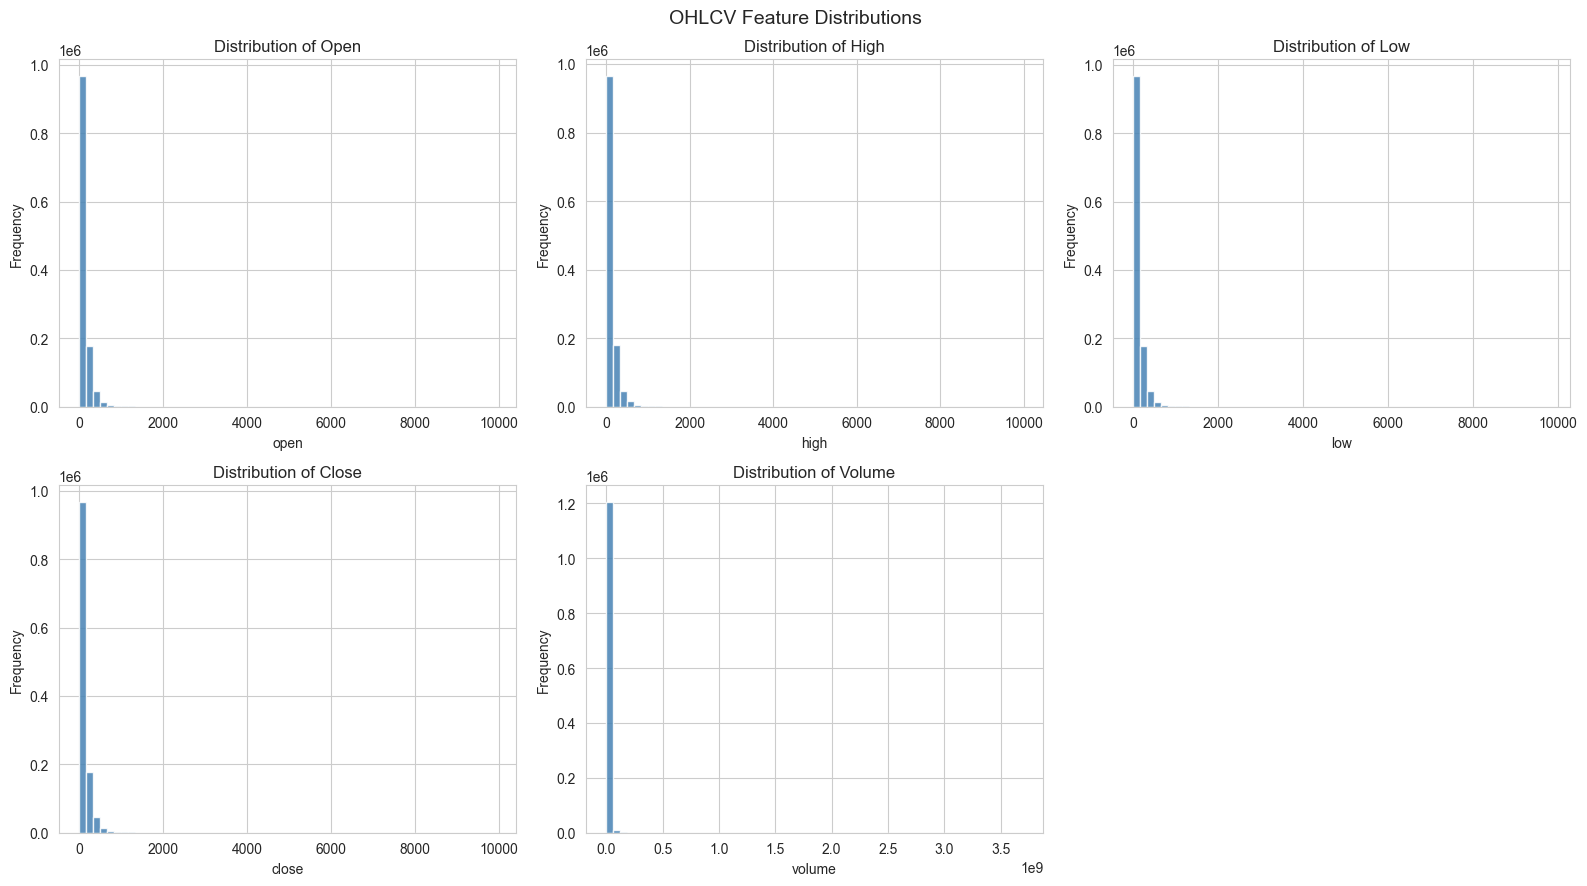

In [15]:
# Histograms for OHLCV columns to visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(['open', 'high', 'low', 'close', 'volume']):
    axes[i].hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('OHLCV Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Step:6 Correlation & Relationship Analysis

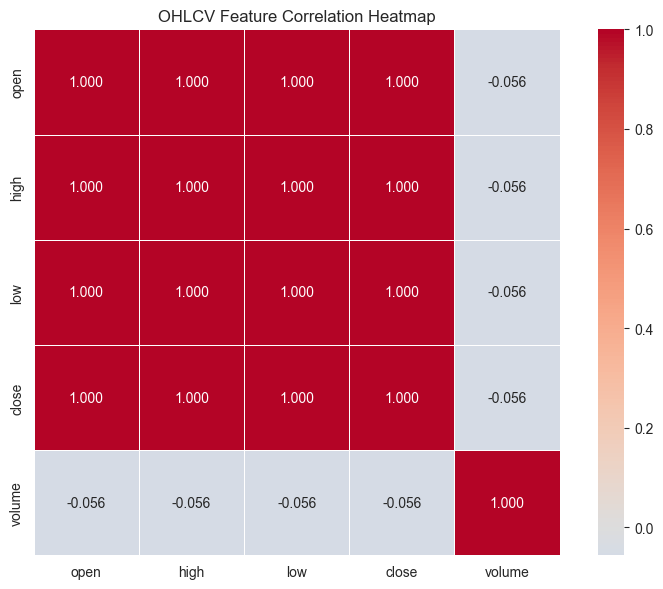


Interpretation: Open/High/Low/Close are strongly correlated (multicollinearity risk).
Volume has weaker correlation - may be a useful independent signal.


In [16]:
# Correlation heatmap for OHLCV features
corr = df[['open', 'high', 'low', 'close', 'volume']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('OHLCV Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
print("\nInterpretation: Open/High/Low/Close are strongly correlated (multicollinearity risk).")
print("Volume has weaker correlation - may be a useful independent signal.")

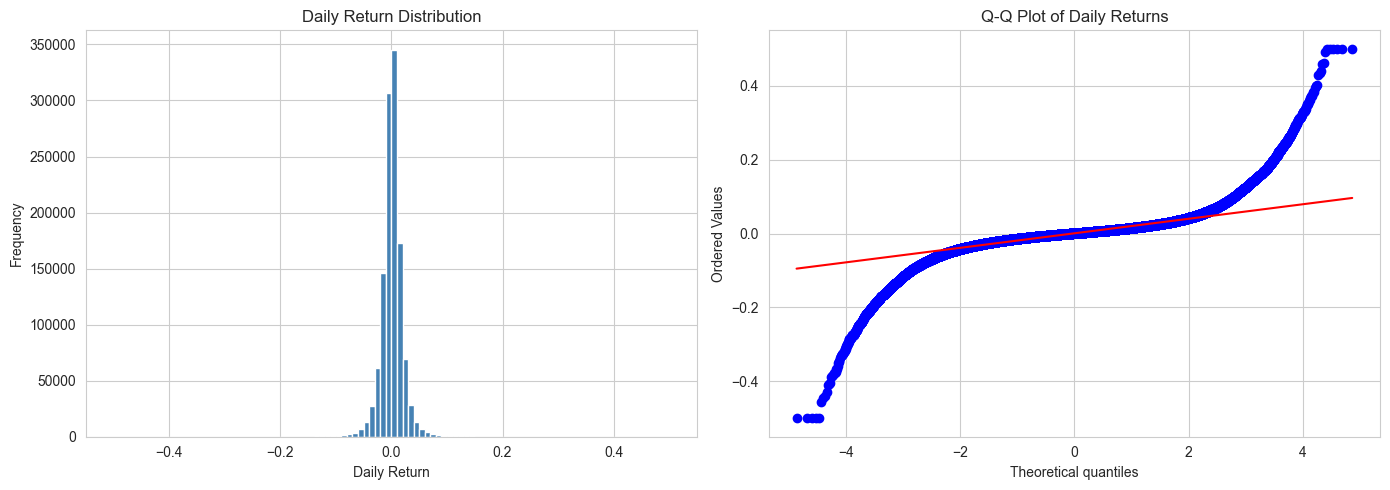

Skewness: 0.1919
Kurtosis: 25.6717


In [17]:
# Daily return distribution and Q-Q plot
df = df.sort_values(['symbol', 'date'])
df['daily_return'] = df.groupby('symbol')['close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['daily_return'].dropna().clip(-0.5, 0.5).plot(
    kind='hist', bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('Daily Return Distribution')
axes[0].set_xlabel('Daily Return')

stats.probplot(df['daily_return'].dropna().clip(-0.5, 0.5), plot=axes[1])
axes[1].set_title('Q-Q Plot of Daily Returns')
plt.tight_layout()
plt.show()

print("Skewness:", round(df['daily_return'].skew(), 4))
print("Kurtosis:", round(df['daily_return'].kurtosis(), 4))

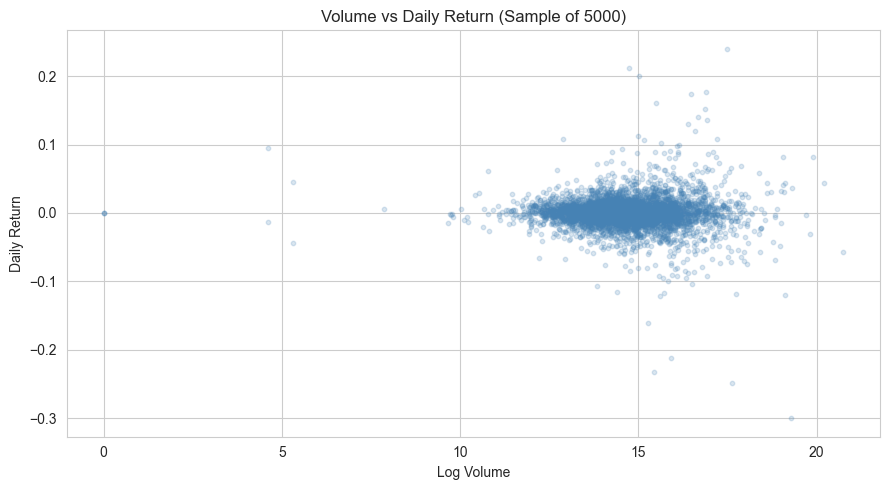

In [18]:
# Scatter plot of volume vs daily return (using a sample for clarity)
sample = df[['volume', 'daily_return']].dropna().sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(np.log1p(sample['volume']), sample['daily_return'].clip(-0.3, 0.3),
           alpha=0.2, s=10, color='steelblue')
ax.set_xlabel('Log Volume')
ax.set_ylabel('Daily Return')
ax.set_title('Volume vs Daily Return (Sample of 5000)')
plt.tight_layout()
plt.show()

## Step:7 Time Series Trend Analysis

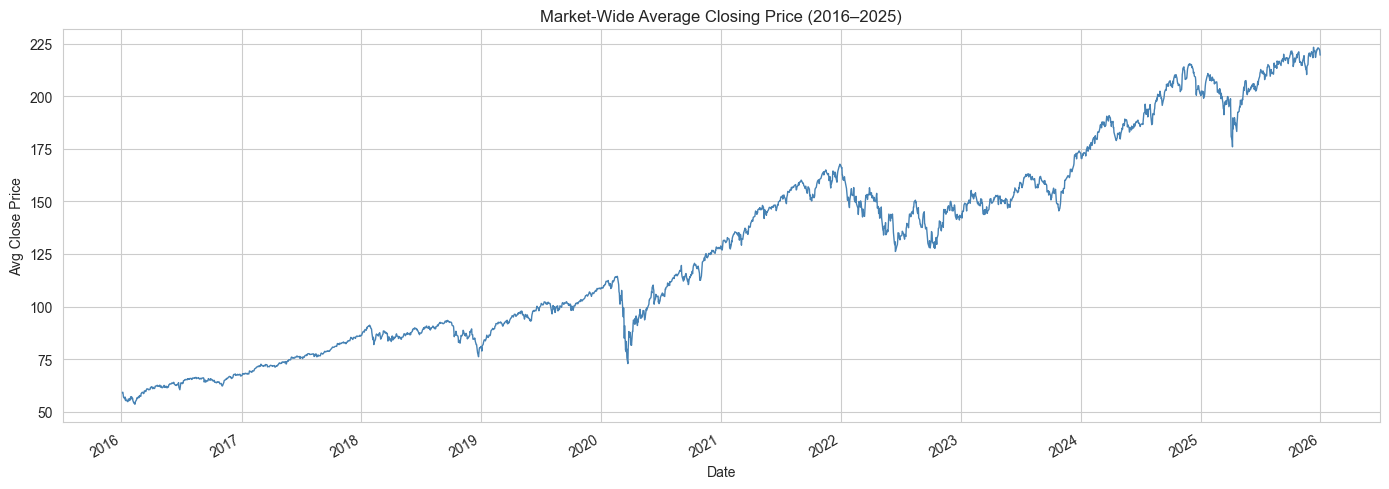

In [19]:
# Market-wide average closing price over time
daily_avg = df.groupby('date')['close'].mean()
fig, ax = plt.subplots(figsize=(14, 5))
daily_avg.plot(ax=ax, color='steelblue', linewidth=1)
ax.set_title('Market-Wide Average Closing Price (2016–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Close Price')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

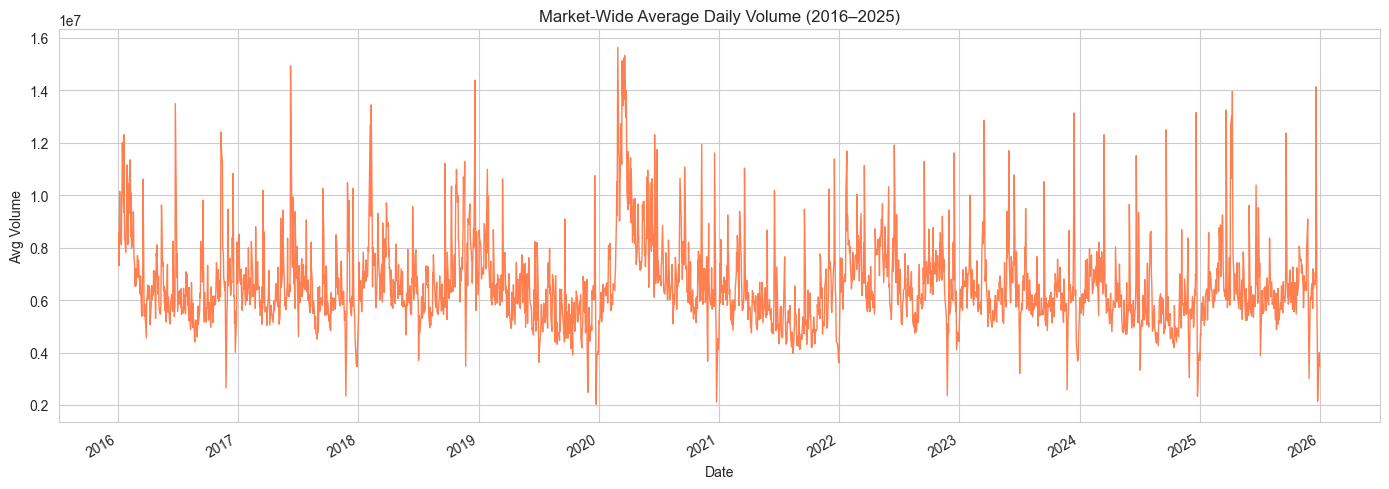

In [20]:
# Average daily volume over time
daily_vol = df.groupby('date')['volume'].mean()
fig, ax = plt.subplots(figsize=(14, 5))
daily_vol.plot(ax=ax, color='coral', linewidth=1)
ax.set_title('Market-Wide Average Daily Volume (2016–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Volume')
plt.tight_layout()
plt.show()

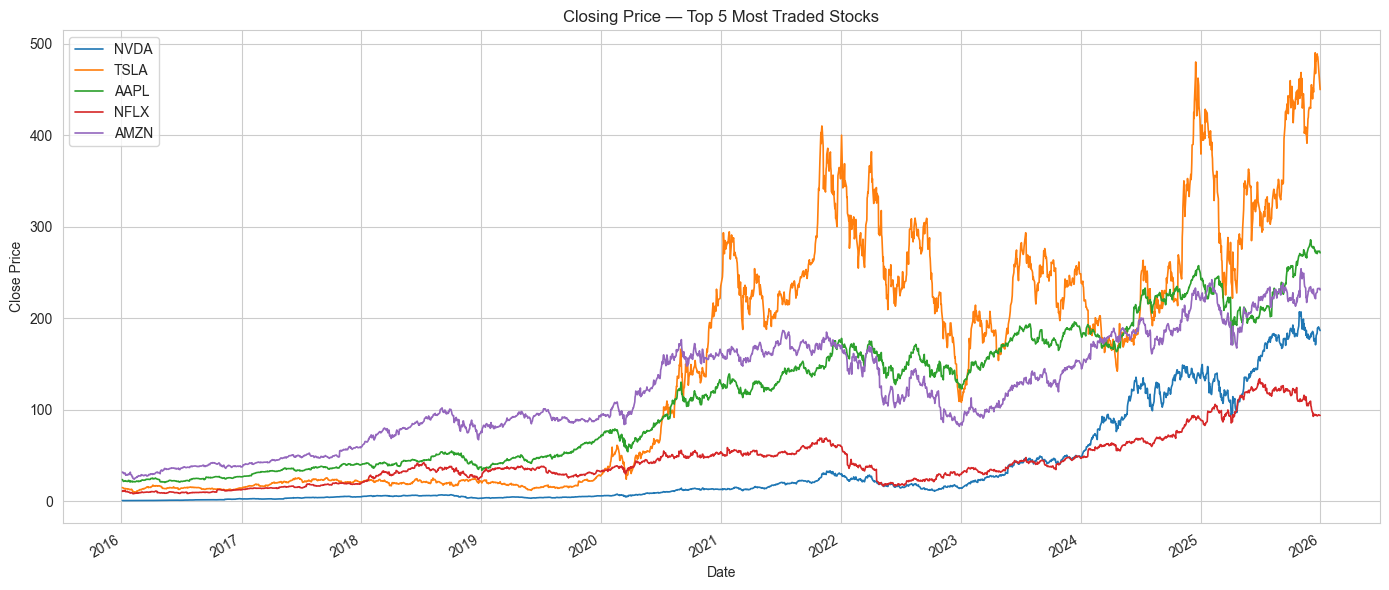

In [21]:
# Price trend for top 5 stocks by avg volume
top5 = symbol_stats.sort_values('avg_volume', ascending=False).head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
for sym in top5:
    subset = df[df['symbol'] == sym].set_index('date')['close']
    subset.plot(ax=ax, label=sym, linewidth=1.2)
ax.set_title('Closing Price — Top 5 Most Traded Stocks')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')
ax.legend()
plt.tight_layout()
plt.show()

## Step:8 Market Volatility Analysis

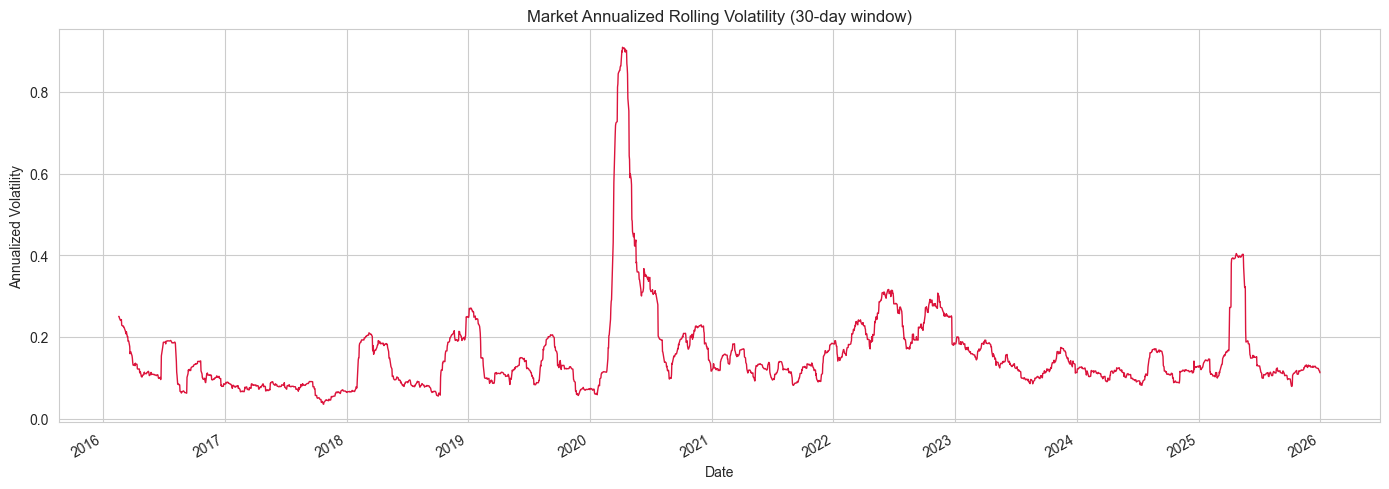

In [22]:
# Rolling volatility of the market (using daily returns)
market_returns = df.groupby('date')['daily_return'].mean()
rolling_vol = market_returns.rolling(30).std() * np.sqrt(252)  # annualized

fig, ax = plt.subplots(figsize=(14, 5))
rolling_vol.plot(ax=ax, color='crimson', linewidth=1)
ax.set_title('Market Annualized Rolling Volatility (30-day window)')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
plt.tight_layout()
plt.show()
# This should clearly show 2020 COVID spike and other market events

## Step:9 Class Distribution/Target Variable analysis

Class distribution:
 target
1.0    0.5241
0.0    0.4759
Name: proportion, dtype: float64


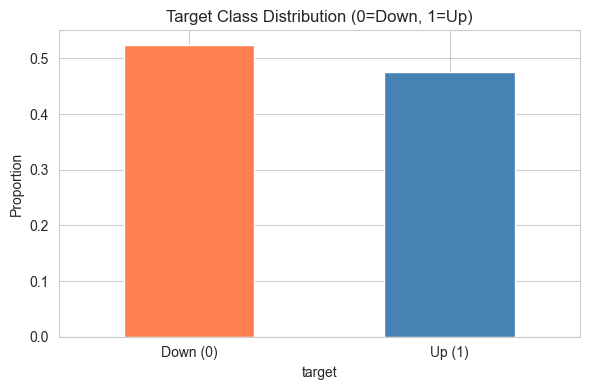

In [23]:
# Define the target variable: 1 if next day's close is higher than today's, else 0
df['target'] = (df.groupby('symbol')['close'].shift(-1) > df['close']).astype(float)

class_dist = df['target'].value_counts(normalize=True)
print("Class distribution:\n", class_dist.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
class_dist.plot(kind='bar', ax=ax, color=['coral', 'steelblue'])
ax.set_title('Target Class Distribution (0=Down, 1=Up)')
ax.set_xticklabels(['Down (0)', 'Up (1)'], rotation=0)
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.show()

## Step:10 Data Quality Summary

In [24]:
# Summary Table

print("DATA QUALITY SUMMARY")
print("")
print(f"Total records:          {len(df):,}")
print(f"Unique stocks:          {df['symbol'].nunique()}")
print(f"Date range:             {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Missing values (any):   {df.isnull().any(axis=1).sum():,}")
print(f"Duplicate rows:         {df.duplicated().sum():,}")
print(f"Invalid OHLC rows:      {(df['high'] < df['low']).sum():,}")
print(f"Stocks w/ <90% cover:   {len(incomplete_stocks)}")

DATA QUALITY SUMMARY

Total records:          1,220,278
Unique stocks:          500
Date range:             2016-01-04 -> 2025-12-31
Missing values (any):   500
Duplicate rows:         0
Invalid OHLC rows:      0
Stocks w/ <90% cover:   30


## Step:11 Per Symbol Normalization

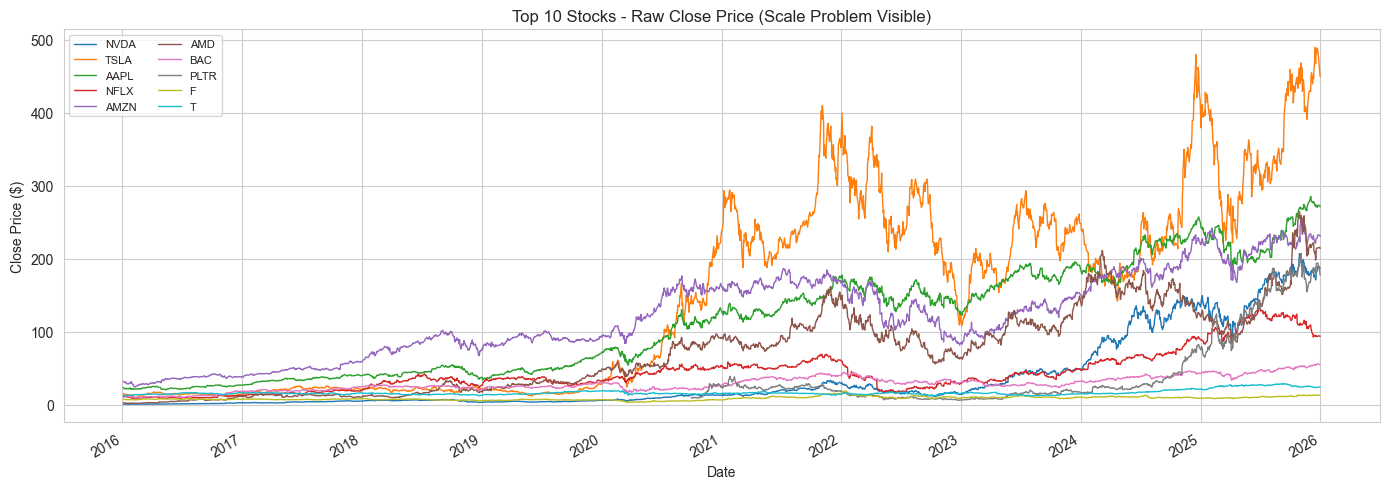

Stocks trade at vastly different price scales.
   High-priced stocks will dominate model training without normalization.


In [32]:
# STEP 11: Per-Symbol Normalization for EDA Visualization
# Purpose: Demonstrate price scale differences across stocks
# and show normalization as a preprocessing insight


from sklearn.preprocessing import MinMaxScaler

# Calculate average volume per stock to identify top 10 by trading activity
# Problem before npormalization: High-priced stocks (e.g., $1000+) will dwarf low-priced stocks (e.g., $10) in raw price plots
top10 = symbol_stats.sort_values('avg_volume', ascending=False).head(10).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
for sym in top10:
    subset = df[df['symbol'] == sym].set_index('date')['close']
    subset.plot(ax=ax, label=sym, linewidth=1)
ax.set_title('Top 10 Stocks - Raw Close Price (Scale Problem Visible)')
ax.set_ylabel('Close Price ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
print("Stocks trade at vastly different price scales.")
print("   High-priced stocks will dominate model training without normalization.")

In [33]:
# Apply Min-Max normalization per stock to scale prices to 0-1 range
def normalize_per_symbol(df, cols):
    """ 
    Normalize each stock independently to a 0 to 1 range. 
    The price columns are converted to float first so pandas 
    can store the normalized values without dtype errors. 
    """ 
    df_norm = df.copy() 
    df_norm[cols] = df_norm[cols].astype(float) 
    scaler = MinMaxScaler() 
    
    for sym in df_norm['symbol'].unique(): 
        mask = df_norm['symbol'] == sym 
        df_norm.loc[mask, cols] = scaler.fit_transform(df_norm.loc[mask, cols]) 
    
    return df_norm

price_cols = ['open', 'high', 'low', 'close', 'volume']
df_normalized = normalize_per_symbol(df_clean, price_cols)

print("Per-symbol normalization applied.")
print("\nNormalized data sample:")
print(df_normalized[['symbol', 'date'] + price_cols].head(10).round(4))

Per-symbol normalization applied.

Normalized data sample:
  symbol       date    open    high     low   close  volume
0  BRK-B 2016-01-08  0.0145  0.0110  0.0113  0.0101  0.2698
1  BRK-B 2016-01-13  0.0118  0.0085  0.0052  0.0051  0.2671
2  BRK-B 2016-01-15  0.0030  0.0023  0.0023  0.0048  0.3619
3  BRK-B 2016-01-29  0.0062  0.0094  0.0062  0.0136  0.2888
4  BRK-B 2016-02-03  0.0054  0.0019  0.0000  0.0051  0.2926
5  BRK-B 2016-02-12  0.0064  0.0057  0.0061  0.0095  0.2277
6  BRK-B 2016-02-25  0.0182  0.0157  0.0167  0.0197  0.1526
7  BRK-B 2016-03-01  0.0267  0.0267  0.0262  0.0308  0.2683
8  BRK-B 2016-03-15  0.0364  0.0350  0.0376  0.0391  0.1226
9  BRK-B 2016-04-07  0.0408  0.0369  0.0406  0.0401  0.1263


C:\Users\Admin\AppData\Local\Temp\ipykernel_31400\405078585.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df_normalized[['symbol', 'date'] + price_cols].head(10).round(4))


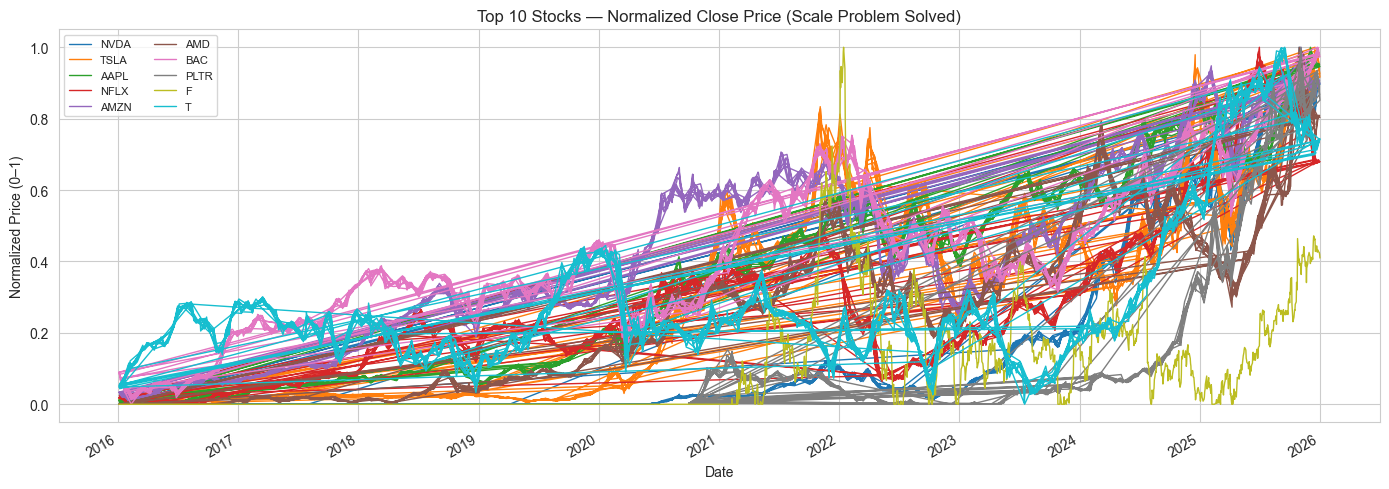

All stocks now on same [0,1] scale - fair comparison enabled.


In [34]:
# Solution: Now all stocks are on the same 0-1 scale, allowing for fair visual comparison of price trends across different stocks regardless of their original price levels.
fig, ax = plt.subplots(figsize=(14, 5))
for sym in top10:
    subset = df_normalized[df_normalized['symbol'] == sym].set_index('date')['close']
    subset.plot(ax=ax, label=sym, linewidth=1)
ax.set_title('Top 10 Stocks — Normalized Close Price (Scale Problem Solved)')
ax.set_ylabel('Normalized Price (0–1)')
ax.set_xlabel('Date')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
print("All stocks now on same [0,1] scale - fair comparison enabled.")

In [35]:
# ── 11d. Verify normalization integrity ───────────────────────────────
norm_check = df_normalized.groupby('symbol')[price_cols].agg(['min', 'max'])
print("\nMin values after normalization (should all be ~0.0):")
print(norm_check.xs('min', axis=1, level=1).describe().round(4))
print("\nMax values after normalization (should all be ~1.0):")
print(norm_check.xs('max', axis=1, level=1).describe().round(4))


Min values after normalization (should all be ~0.0):
        open   high    low  close  volume
count  500.0  500.0  500.0  500.0   500.0
mean     0.0    0.0    0.0    0.0     0.0
std      0.0    0.0    0.0    0.0     0.0
min      0.0    0.0    0.0    0.0     0.0
25%      0.0    0.0    0.0    0.0     0.0
50%      0.0    0.0    0.0    0.0     0.0
75%      0.0    0.0    0.0    0.0     0.0
max      0.0    0.0    0.0    0.0     0.0

Max values after normalization (should all be ~1.0):
           open      high       low     close  volume
count  500.0000  500.0000  500.0000  500.0000   500.0
mean     0.9980    0.9980    0.9980    0.9980     1.0
std      0.0447    0.0447    0.0447    0.0447     0.0
min      0.0000    0.0000    0.0000    0.0000     1.0
25%      1.0000    1.0000    1.0000    1.0000     1.0
50%      1.0000    1.0000    1.0000    1.0000     1.0
75%      1.0000    1.0000    1.0000    1.0000     1.0
max      1.0000    1.0000    1.0000    1.0000     1.0
